In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import psycopg2

In [2]:
# Create database(PostgreSQL) connection.
conn= psycopg2.connect(
    database='brazilian e-commerce DB',
    host='localhost',
    password='your password',
    user='postgres'
)
cursor=conn.cursor()

In [3]:
from sqlalchemy import create_engine

engine=create_engine(
    "postgresql+psycopg2://postgres:your passwordlocalhost:5432/brazilian e-commerce DB"
)
conn=engine.connect()


In [4]:
# Load order data from Postgresql.
df= pd.read_sql_query('''select * from order_level''',engine)
display(df)

,order_id,order_item_id,price,customer_id,order_status,order_date,delivery_date,estimated_delivery_date,product_id,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,2017-09-20 23:43:00,2017-09-29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,2017-05-12 16:04:00,2017-05-15,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,199.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,2018-01-22 13:19:00,2018-02-05,c777355d18b72b67abbeef9df44fd0fd,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,2018-08-14 13:32:00,2018-08-20,7634da152a4610f1595efa32f14722fc,perfumery
4,00048cc3ae777c65dbb7d2a0634bc1ea,1,21.90,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:00,2017-05-22 13:44:00,2017-06-06,ef92defde845ab8450f9d70c526ef70f,housewares
...,...,...,...,...,...,...,...,...,...,...
112645,fff6889749958e42b47a7977a4cf0ea0,1,92.00,c5d108ecadaedf367e995520d36c9b1d,delivered,2017-09-25 22:41:00,2017-09-28 22:38:00,2017-10-10,75f6a4f019ec1322758d53b2fee2cc12,luggage_accessories
112646,fff6b8ca971f8e3ec822e99d0f2d3d21,1,199.00,2aec499f94f5e82786629a84b816ffb9,delivered,2017-09-15 11:44:00,2017-09-21 19:34:00,2017-10-04,9afaad66aca8b0c79e4f084a89c9c92b,telephony
112647,fff8287bbae429a99bb7e8c21d151c41,1,180.00,6c1e92a209dbf868706caa831090941e,delivered,2018-03-17 12:11:00,2018-04-07 10:07:00,2018-04-19,bee2e070c39f3dd2f6883a17a5f0da45,computers_accessories
112648,fff8287bbae429a99bb7e8c21d151c41,2,180.00,6c1e92a209dbf868706caa831090941e,delivered,2018-03-17 12:11:00,2018-04-07 10:07:00,2018-04-19,bee2e070c39f3dd2f6883a17a5f0da45,computers_accessories


# Exploratory Data Analysis
 - Examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

 - In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.




In [5]:
# Summary statistic for numeric columns.
df.describe()

,order_item_id,price,order_date,delivery_date,estimated_delivery_date
count,112650.000000,112650.000000,112650,112650,112650
mean,1.197834,120.653739,2018-01-01 00:09:18.945938688,2018-01-13 18:07:29.692676352,2018-01-24 20:12:15.531291392
min,1.000000,0.850000,2016-09-04 21:15:00,2016-10-11 13:46:00,2016-10-04 00:00:00
25%,1.000000,39.900000,2017-09-13 19:17:00,2017-09-25 20:13:15,2017-10-05 00:00:00
50%,1.000000,74.990000,2018-01-19 23:02:00,2018-02-02 15:17:30,2018-02-16 00:00:00
75%,1.000000,134.900000,2018-05-04 17:30:15,2018-05-15 17:35:30,2018-05-28 00:00:00
max,21.000000,6735.000000,2018-09-03 09:06:00,2018-10-17 13:22:00,2018-10-25 00:00:00
std,0.705124,183.633928,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   order_id                 112650 non-null  object        
 1   order_item_id            112650 non-null  int64         
 2   price                    112650 non-null  float64       
 3   customer_id              112650 non-null  object        
 4   order_status             112650 non-null  object        
 5   order_date               112650 non-null  datetime64[ns]
 6   delivery_date            112650 non-null  datetime64[ns]
 7   estimated_delivery_date  112650 non-null  datetime64[ns]
 8   product_id               112650 non-null  object        
 9   product_category         112650 non-null  object        
dtypes: datetime64[ns](3), float64(1), int64(1), object(5)
memory usage: 8.6+ MB


In [7]:
df.dtypes

order_id                           object
order_item_id                       int64
price                             float64
customer_id                        object
order_status                       object
order_date                 datetime64[ns]
delivery_date              datetime64[ns]
estimated_delivery_date    datetime64[ns]
product_id                         object
product_category                   object
dtype: object

In [8]:
# Filter deliverd order.
df_delivered=df[df['order_status']=='delivered']
df_delivered

,order_id,order_item_id,price,customer_id,order_status,order_date,delivery_date,estimated_delivery_date,product_id,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:00,2017-09-20 23:43:00,2017-09-29,4244733e06e7ecb4970a6e2683c13e61,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:00,2017-05-12 16:04:00,2017-05-15,e5f2d52b802189ee658865ca93d83a8f,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,199.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:00,2018-01-22 13:19:00,2018-02-05,c777355d18b72b67abbeef9df44fd0fd,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:00,2018-08-14 13:32:00,2018-08-20,7634da152a4610f1595efa32f14722fc,perfumery
4,00048cc3ae777c65dbb7d2a0634bc1ea,1,21.90,816cbea969fe5b689b39cfc97a506742,delivered,2017-05-15 21:42:00,2017-05-22 13:44:00,2017-06-06,ef92defde845ab8450f9d70c526ef70f,housewares
...,...,...,...,...,...,...,...,...,...,...
112645,fff6889749958e42b47a7977a4cf0ea0,1,92.00,c5d108ecadaedf367e995520d36c9b1d,delivered,2017-09-25 22:41:00,2017-09-28 22:38:00,2017-10-10,75f6a4f019ec1322758d53b2fee2cc12,luggage_accessories
112646,fff6b8ca971f8e3ec822e99d0f2d3d21,1,199.00,2aec499f94f5e82786629a84b816ffb9,delivered,2017-09-15 11:44:00,2017-09-21 19:34:00,2017-10-04,9afaad66aca8b0c79e4f084a89c9c92b,telephony
112647,fff8287bbae429a99bb7e8c21d151c41,1,180.00,6c1e92a209dbf868706caa831090941e,delivered,2018-03-17 12:11:00,2018-04-07 10:07:00,2018-04-19,bee2e070c39f3dd2f6883a17a5f0da45,computers_accessories
112648,fff8287bbae429a99bb7e8c21d151c41,2,180.00,6c1e92a209dbf868706caa831090941e,delivered,2018-03-17 12:11:00,2018-04-07 10:07:00,2018-04-19,bee2e070c39f3dd2f6883a17a5f0da45,computers_accessories


## KPI'S

In [9]:
total_orders=len(df_delivered)
thousand=total_orders/10000
print("total no of orders:",f'{total_orders:.2f}K')

total_sale=df_delivered['price'].sum()
millions= total_sale/ 1000000
print("total sale:",f'{millions:.2f}M')

AOV=total_sale/total_orders
print("avg order value:",round(AOV,2))

total no of orders: 110197.00K
total sale: 13.22M
avg order value: 119.98


##  Identify outlier and distribution of price columns.

<Axes: xlabel='price', ylabel='Count'>

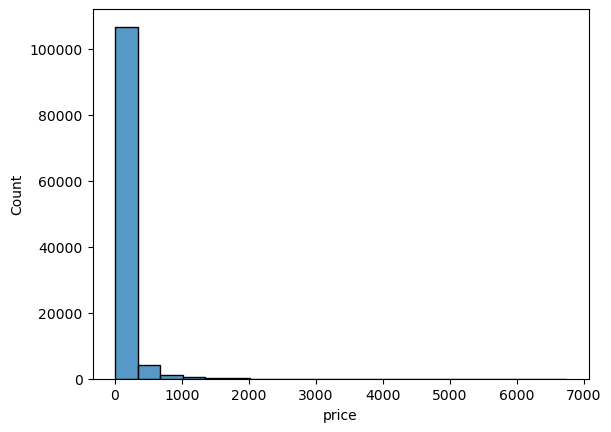

In [10]:
# distribution plot 
sns.histplot(df['price'],bins=20)


<Axes: ylabel='price'>

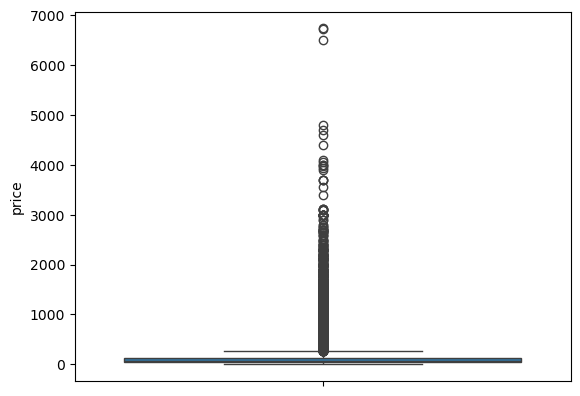

In [11]:
# Outlier identify.
sns.boxplot(df['price'])

# Charts

## Total sales trend

In [12]:
def format_revenue(price):
    if price>= 1_000_000:
        return f"{price/1_000_000:.2f}M"
    elif price>=1_000:
        return f"{price/1_000:.0f}K"
    else:
        return str(price)

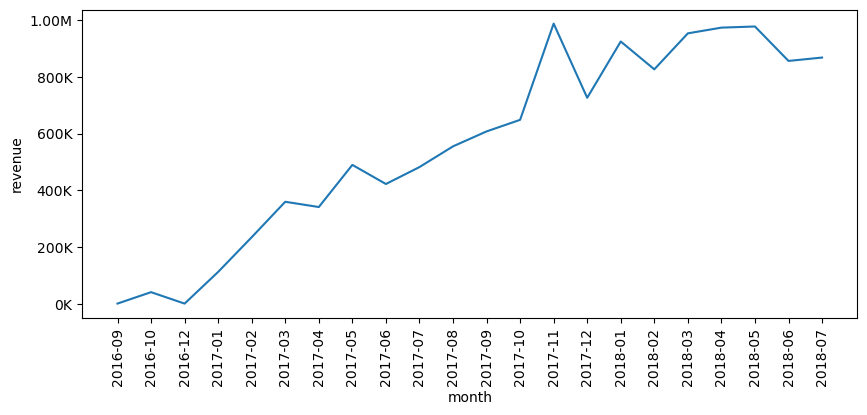

In [13]:
df1=df[df['order_status']=='delivered'].copy()
df1['price']=pd.to_numeric(df1['price'],errors='coerce')
df1["yearmonth"]=df1["order_date"].dt.to_period("M")
monthly_revenue=df1.groupby("yearmonth")["price"].sum().reset_index()

#remove last month (only have 1 day data from perticular month)
monthly_revenue=monthly_revenue[monthly_revenue['yearmonth']<monthly_revenue['yearmonth'].max()]

#Line plot for monthly sales
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly_revenue["yearmonth"].astype(str),monthly_revenue["price"])

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x,_:
                        f"{x/1_000_000:.2f}M" if x>=1_000_000
                        else f"{x/1_000:.0f}K")
)

plt.xticks(rotation=90)
plt.xlabel("month")
plt.ylabel("revenue")
plt.show()

In [14]:
monthly_revenue['growth%']=round(monthly_revenue['price'].pct_change()*100,2)
monthly_revenue

,yearmonth,price,growth%
0,2016-09,134.97,NaN
1,2016-10,40325.11,29777.09
2,2016-12,10.90,-99.97
3,2017-01,111798.36,1025573.03
4,2017-02,234223.40,109.51
5,2017-03,359198.85,53.36
6,2017-04,340669.68,-5.16
7,2017-05,489338.25,43.64
8,2017-06,421923.37,-13.78
9,2017-07,481604.52,14.15


In [15]:
#Calculate total  orders by month.
df_sales=df[df['order_status']=='delivered'].copy()
df_sales["yearmonth"]=df_sales["order_date"].dt.to_period("M")

monthly_orders=df_sales.groupby("yearmonth").agg({
    'order_id':'nunique',
     "price":"sum"
}).reset_index()
monthly_orders['revenue']=monthly_orders['price'].apply(format_revenue)
monthly_orders



,yearmonth,order_id,price,revenue
0,2016-09,1,134.97,134.97
1,2016-10,265,40325.11,40K
2,2016-12,1,10.90,10.9
3,2017-01,750,111798.36,112K
4,2017-02,1653,234223.40,234K
5,2017-03,2546,359198.85,359K
6,2017-04,2303,340669.68,341K
7,2017-05,3546,489338.25,489K
8,2017-06,3135,421923.37,422K
9,2017-07,3872,481604.52,482K


## New vs repeat customer trend

In [16]:
#count repeat customers.
df['yearmonth']=df['order_date'].dt.to_period('M').astype(str)
df['repeat_customer']=df.duplicated('customer_id')
order_count=df['repeat_customer'].value_counts()
#order_count['repeat%']=order_count['repeat_customer'].pct_change() * 100
order_count

repeat_customer
False    98666
True     13984
Name: count, dtype: int64

In [17]:
#group by new and repeat customer by monthwise
data=df.groupby(['yearmonth','repeat_customer'])['order_id'].count().unstack()
data.columns=['new_customer','repeat']
data=data.reset_index()

data['new_cus%']=data['new_customer'].pct_change() *100
data['repeat%']=data['repeat']/data['new_customer'] * 100

#remove last month (only have 1 day data from perticular month)
datac=data[data['yearmonth']<data['yearmonth'].max()]
print(datac)



   yearmonth  new_customer  repeat      new_cus%     repeat%
0    2016-09           3.0     3.0           NaN  100.000000
1    2016-10         308.0    55.0  10166.666667   17.857143
2    2016-12           1.0     NaN    -99.675325         NaN
3    2017-01         789.0   166.0  78800.000000   21.039290
4    2017-02        1733.0   218.0    119.645120   12.579342
5    2017-03        2641.0   359.0     52.394691   13.593336
6    2017-04        2391.0   293.0     -9.466111   12.254287
7    2017-05        3660.0   476.0     53.074028   13.005464
8    2017-06        3217.0   366.0    -12.103825   11.377059
9    2017-07        3969.0   550.0     23.375816   13.857395
10   2017-08        4293.0   617.0      8.163265   14.372234
11   2017-09        4243.0   588.0     -1.164687   13.858119
12   2017-10        4568.0   754.0      7.659675   16.506130
13   2017-11        7451.0  1214.0     63.112960   16.293115
14   2017-12        5624.0   684.0    -24.520199   12.162162
15   2018-01        7220

In [18]:
data.columns

Index(['yearmonth', 'new_customer', 'repeat', 'new_cus%', 'repeat%'], dtype='object')

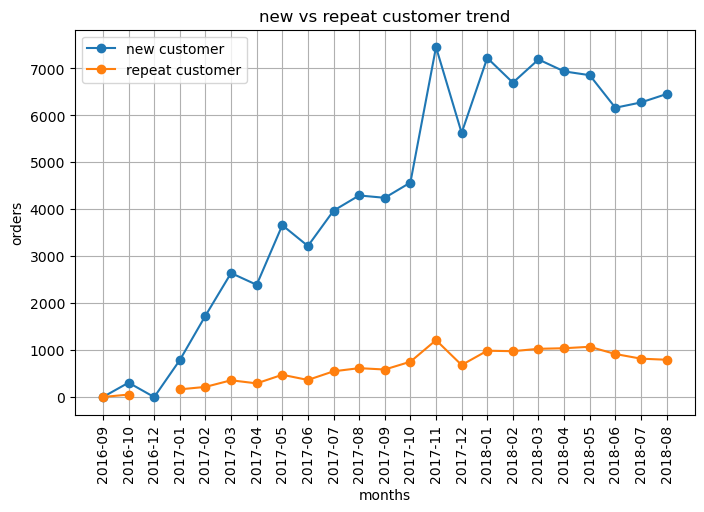

In [19]:
# Compare monthwise new and repeat customers.
plt.figure(figsize=(8,5))
plt.plot(datac['yearmonth'],datac['new_customer'],label='new customer',marker='o')
plt.plot(datac['yearmonth'],datac['repeat'],label='repeat customer',marker='o')

plt.title("new vs repeat customer trend")
plt.xlabel("months")
plt.ylabel('orders')
plt.xticks(rotation=90)
plt.legend()
plt.grid()
plt.show()

### New vs repeat customer chart insight:
-The chart shows new customer has increases over the months and repeat customer is inflated.This indicate that customers are not satisfied with the business.           
         -Target high purchase product with offer, create loyality programs for top customers to increase repeat rate.

# Delivery delay empact

In [20]:
df['delivery_date']=pd.to_datetime(df['delivery_date'])
df['estimated_delivery_date']=pd.to_datetime(df['estimated_delivery_date'])                                                        
df['delivery_days']=(df['delivery_date']-df['estimated_delivery_date']).dt.days

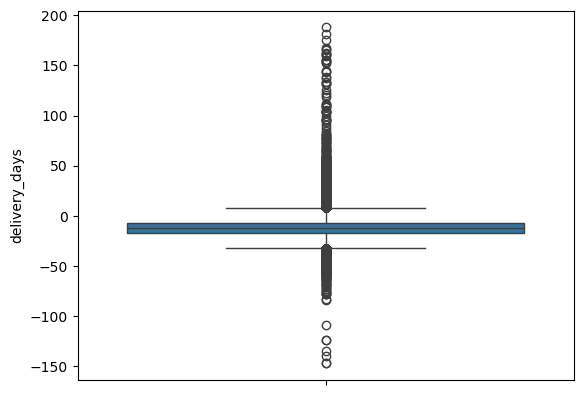

In [21]:
sns.boxplot(df['delivery_days'])
plt.show()

#### Many deliveries are delay for more than 50 days.This company need to optimize logistic / inventory .

In [22]:
#New column for delay days 
df['delivery_date']=pd.to_datetime(df['delivery_date'])
df['estimated_delivery_date']=pd.to_datetime(df['estimated_delivery_date'])

df['delivery_days']=(df['delivery_date']-df['estimated_delivery_date']).dt.days

In [23]:
#sort customer_id with order date to find repeate customer with their first purchase date.
df=df.sort_values(['customer_id','order_date'])

# Group by  customers with their total orders.
customer_orders=df.groupby('customer_id')['order_id'].count().reset_index()
customer_orders.columns=['customer_id','order_count']

# Identify repeat customers.
customer_orders['is_repeat']=customer_orders['order_count']>1
customer_orders

,customer_id,order_count,is_repeat
0,00012a2ce6f8dcda20d059ce98491703,1,False
1,000161a058600d5901f007fab4c27140,1,False
2,0001fd6190edaaf884bcaf3d49edf079,1,False
3,0002414f95344307404f0ace7a26f1d5,1,False
4,000379cdec625522490c315e70c7a9fb,1,False
...,...,...,...
98661,fffcb937e9dd47a13f05ecb8290f4d3e,1,False
98662,fffecc9f79fd8c764f843e9951b11341,1,False
98663,fffeda5b6d849fbd39689bb92087f431,1,False
98664,ffff42319e9b2d713724ae527742af25,1,False


In [24]:
df['delivery_type']=df['delivery_days'].apply(lambda x:'on time'if x<=0 else 'delayed')

In [25]:
first_order=df.groupby('customer_id').first().reset_index()
first_order=first_order[['customer_id','delivery_type']]
first_order

,customer_id,delivery_type
0,00012a2ce6f8dcda20d059ce98491703,on time
1,000161a058600d5901f007fab4c27140,on time
2,0001fd6190edaaf884bcaf3d49edf079,on time
3,0002414f95344307404f0ace7a26f1d5,on time
4,000379cdec625522490c315e70c7a9fb,on time
...,...,...
98661,fffcb937e9dd47a13f05ecb8290f4d3e,on time
98662,fffecc9f79fd8c764f843e9951b11341,on time
98663,fffeda5b6d849fbd39689bb92087f431,on time
98664,ffff42319e9b2d713724ae527742af25,on time


In [26]:
#merge customer table and first order table
customer_orders=customer_orders.merge(first_order,on='customer_id')
customer_orders

,customer_id,order_count,is_repeat,delivery_type
0,00012a2ce6f8dcda20d059ce98491703,1,False,on time
1,000161a058600d5901f007fab4c27140,1,False,on time
2,0001fd6190edaaf884bcaf3d49edf079,1,False,on time
3,0002414f95344307404f0ace7a26f1d5,1,False,on time
4,000379cdec625522490c315e70c7a9fb,1,False,on time
...,...,...,...,...
98661,fffcb937e9dd47a13f05ecb8290f4d3e,1,False,on time
98662,fffecc9f79fd8c764f843e9951b11341,1,False,on time
98663,fffeda5b6d849fbd39689bb92087f431,1,False,on time
98664,ffff42319e9b2d713724ae527742af25,1,False,on time


In [27]:
#Compare customer repeate rate between on time and delayed orders.
result=customer_orders.groupby('delivery_type').agg(
    total_customers=('customer_id','count'),
    repeat_customers=('is_repeat','sum')
).reset_index()

result['repeat_rate']=result['repeat_customers']/result['total_customers']*100
result

,delivery_type,total_customers,repeat_customers,repeat_rate
0,delayed,6535,510,7.804132
1,on time,92131,9293,10.086724


In [28]:
df['is_delayed']=df['delivery_days']>0
df

,order_id,order_item_id,price,customer_id,order_status,order_date,delivery_date,estimated_delivery_date,product_id,product_category,yearmonth,repeat_customer,delivery_days,delivery_type,is_delayed
20862,5f79b5b0931d63f1a42989eb65b9da6e,1,89.80,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:00,2017-11-28 15:41:00,2017-12-04,64315bd8c0c47303179dd2e25b579d00,toys,2017-11,False,-6,on time,False
35893,a44895d095d7e0702b6a162fa2dbeced,1,54.90,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:00,2017-07-25 18:57:00,2017-08-04,84183944dc7cddca87a5d384452c1d3c,health_beauty,2017-07,False,-10,on time,False
67104,316a104623542e4d75189bb372bc5f8d,1,179.99,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:00,2017-03-06 08:57:00,2017-03-22,9df2b21ec85378d71df4404712e17478,baby,2017-02,False,-16,on time,False
75762,5825ce2e88d5346438686b0bba99e5ee,1,149.90,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:00,2017-09-13 20:06:00,2017-09-14,af3ec22cce878225aae6d9eb6c7a78eb,cool_stuff,2017-08,False,-1,on time,False
58648,0ab7fb08086d4af9141453c91878ed7a,1,93.00,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:00,2018-04-13 20:21:00,2018-04-18,868b3136c5b206f91b8208fbfdf2cb7c,bed_bath_table,2018-04,False,-5,on time,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28327,814d6a3a7c0b32b2ad929ac6328124e9,1,54.90,fffecc9f79fd8c764f843e9951b11341,delivered,2018-03-29 16:59:00,2018-04-10 17:20:00,2018-04-27,c045b19fdb30a3035c56d04c6fe2e622,bed_bath_table,2018-03,False,-17,on time,False
87169,8c855550908247a7eff50281b92167a8,1,47.90,fffeda5b6d849fbd39689bb92087f431,delivered,2018-05-22 13:36:00,2018-06-08 18:03:00,2018-06-29,d5c263f4d651ba657c900ce70a4be7de,telephony,2018-05,False,-21,on time,False
85285,83b5fc912b2862c5046555ded1483ae9,1,199.90,ffff42319e9b2d713724ae527742af25,delivered,2018-06-13 16:57:00,2018-06-18 18:33:00,2018-06-25,e61c78a7343d82c0539d27df0f7dfc31,bed_bath_table,2018-06,False,-7,on time,False
102344,d0e7be325a1c986babc4e1cdb91edc03,1,10.90,ffffa3172527f765de70084a7e53aae8,delivered,2017-09-02 11:53:00,2017-09-14 19:47:00,2017-09-26,43ee88561093499d9e571d4db5f20b79,furniture_decor,2017-09,False,-12,on time,False


In [29]:
#delayed orders by category.
category_delay=(df.groupby('product_category').agg(
    total_order=('delivery_type','count'),
    delay_order=('is_delayed','sum')
)
 .reset_index())

#delay percentage
category_delay['delay%']=category_delay['delay_order']/category_delay['total_order']*100

category_delay=category_delay.sort_values(by='delay%',ascending=True).tail(10)
category_delay

,product_category,total_order,delay_order,delay%
6,baby,3065,229,7.471452
26,electronics,2767,207,7.481026
57,office_furniture,1691,133,7.865169
10,books_technical,267,21,7.865169
33,fashion_underwear_beach,131,12,9.160305
47,home_confort,434,40,9.216590
12,christmas_supplies,153,15,9.803922
4,audio,364,42,11.538462
41,furniture_mattress_and_upholstery,38,5,13.157895
46,home_comfort_2,30,4,13.333333


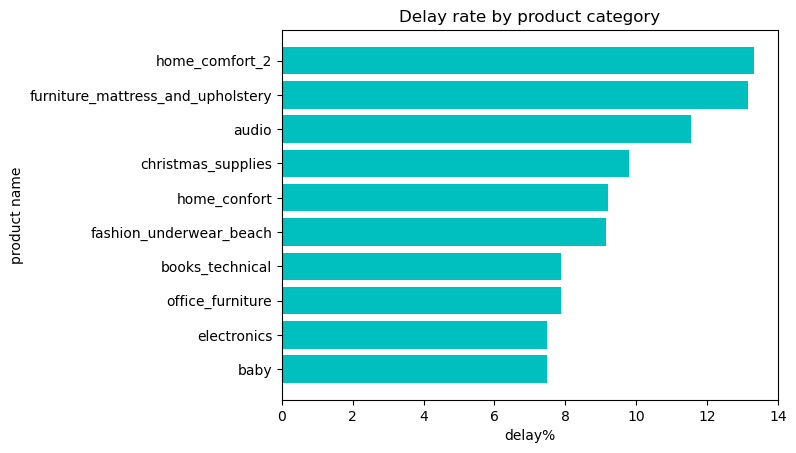

In [30]:
plt.figure()
x=category_delay['product_category']
y=category_delay['delay%']
plt.barh(x,y,color='c')
plt.title('Delay rate by product category')
plt.xlabel('delay%')
plt.ylabel('product name')
plt.show()

## Product analysis

### Which product generate high revenue?

In [31]:
df.columns

Index(['order_id', 'order_item_id', 'price', 'customer_id', 'order_status',
       'order_date', 'delivery_date', 'estimated_delivery_date', 'product_id',
       'product_category', 'yearmonth', 'repeat_customer', 'delivery_days',
       'delivery_type', 'is_delayed'],
      dtype='object')

In [32]:
highrevenueproducts=df.groupby('product_category')['price'].sum().reset_index()
highrevenueproducts.sort_values('price',ascending=False).assign(price=lambda x:x['price'].apply(format_revenue)).head(10)


,product_category,price
43,health_beauty,1.26M
71,watches_gifts,1.21M
7,bed_bath_table,1.04M
65,sports_leisure,988K
15,computers_accessories,912K
39,furniture_decor,730K
20,cool_stuff,635K
49,housewares,632K
5,auto,593K
42,garden_tools,485K


In [33]:
highrevenueproducts['contribution_rate']=highrevenueproducts['price']/highrevenueproducts['price'].sum() *100
highrevenueproducts.sort_values('price',ascending=False).head(10)

,product_category,price,contribution_rate
43,health_beauty,1258681.34,9.260700
71,watches_gifts,1205005.68,8.865783
7,bed_bath_table,1036988.68,7.629605
65,sports_leisure,988048.97,7.269533
15,computers_accessories,911954.32,6.709669
39,furniture_decor,729762.49,5.369200
20,cool_stuff,635290.85,4.674128
49,housewares,632248.66,4.651745
5,auto,592720.11,4.360916
42,garden_tools,485256.46,3.570256


# load customer_level data from PostgreSQL

In [34]:
df1=pd.read_sql_query('''select* from customer_level''',engine)
display(df1)

,customer_id,customer_unique_id,customer_city,customer_state,order_status,quantity,spent_price
0,d0349571985dc0a748ecdd1b6bf25750,527acd5ee1b69a0edddde8fe512007d9,curitiba,PR,delivered,1.0,177.99
1,8fb17055fd54b0e086d5320642721a88,c667c7454243251d3210c6c54a97c482,janauba,MG,delivered,3.0,345.00
2,885aa5f046631ec02ead6b2bea798a92,359a78f03d3fa44893db34ed3564c7ef,campinas,SP,delivered,1.0,89.49
3,3172fe335c9b335ce749eda3b7c73bd3,9e89d2232df792cde636a47212a9f2bb,rio de janeiro,RJ,delivered,1.0,109.90
4,dac766eabb1289d59cb88e34b1489db1,f9721131784ad9d58ba9278236b37845,sao paulo,SP,delivered,1.0,237.00
...,...,...,...,...,...,...,...
99436,8fa9f17f7cc7af41d068b9b3f8df51e8,5105b52fa696cbca4cd3ddade05149fd,abre campo,MG,canceled,0.0,0.00
99437,bffd28b4af20bc7b1a477fe80e190c77,20763743ec53eec3a9949781bf459e6e,barra velha,SC,unavailable,0.0,0.00
99438,e016de14d2abd37825c4c485cd780b74,e7bb82dae3998954497289418e677dc2,sao gabriel,RS,canceled,0.0,0.00
99439,a5569eafa093045938b448b5f802032d,5bdff994fa115621df0b714401ec5db4,jau,SP,unavailable,0.0,0.00


In [35]:
df1['customer_unique_id'].nunique()

96096

In [36]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         99441 non-null  object 
 1   customer_unique_id  99441 non-null  object 
 2   customer_city       99441 non-null  object 
 3   customer_state      99441 non-null  object 
 4   order_status        99441 non-null  object 
 5   quantity            99441 non-null  float64
 6   spent_price         99441 non-null  float64
dtypes: float64(2), object(5)
memory usage: 5.3+ MB


In [37]:
countcustomer=df1.groupby('order_status')['customer_id'].nunique()
print(countcustomer)


order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: customer_id, dtype: int64


## Identifying outliers  using boxplot.

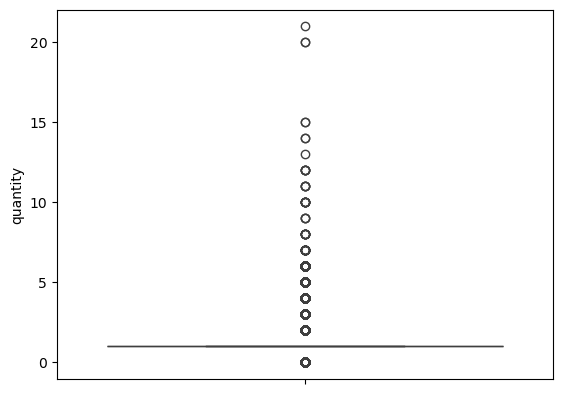

In [38]:
x=df1['quantity']
sns.boxplot(x)
plt.show()

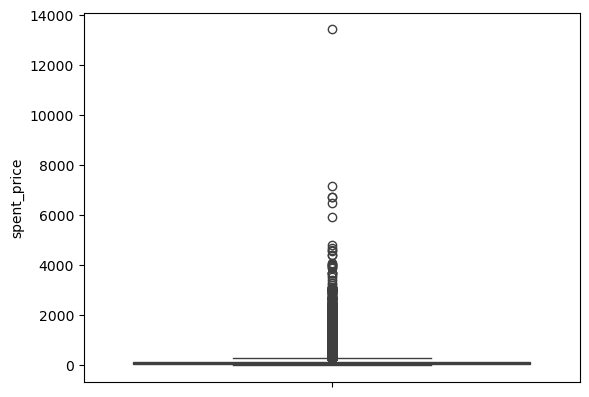

In [39]:
y=df1['spent_price']
sns.boxplot(y)
plt.show()

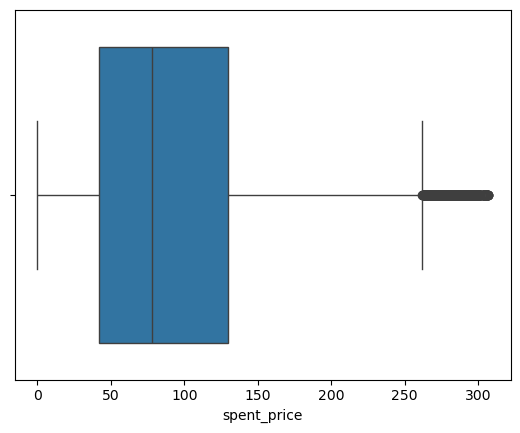

In [40]:

q1=df1['spent_price'].quantile(0.25)
q3=df1['spent_price'].quantile(0.75)
iqr=q3-q1

filtered=df1[(df1['spent_price']>=q1 - 1.5 * iqr) &
            (df1['spent_price']<=q3 + 1.5 *iqr)]

sns.boxplot(x=filtered['spent_price'])
plt.show()

## Top customers by spend price and their purchase contribution.

In [41]:
top_customer=df1.groupby('customer_unique_id').agg({
    'spent_price':'sum'
}).reset_index()
top10_customer=top_customer.sort_values(['spent_price'],ascending=True).tail(10)

display(top10_customer)

,customer_unique_id,spent_price
27441,48e1ac109decbb87765a3eade6854098,4590.0
35070,5d0a2980b292d049061542014e8960bf,4599.9
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4690.0
24121,4007669dec559734d6f53e029e360987,5934.6
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6499.0
26205,459bef486812aa25204be022145caa62,6729.0
82808,dc4802a71eae9be1dd28f5d788ceb526,6735.0
44447,763c8b1c9c68a0229c42c9fc6f662b93,7160.0
81962,da122df9eeddfedc1dc1f5349a1a690c,7388.0
3826,0a0a92112bd4c708ca5fde585afaa872,13440.0


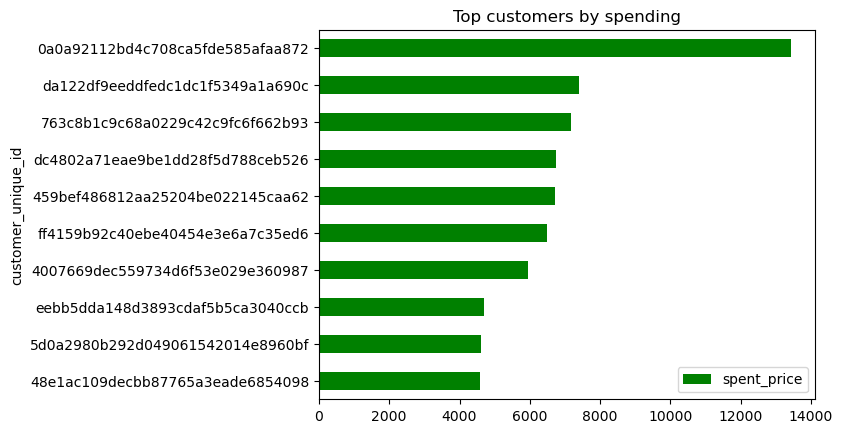

In [42]:
top10_customer.plot(
    kind='barh',
    x='customer_unique_id',
    y='spent_price',
    color='g'
    )
plt.title('Top customers by spending')
plt.show()

In [43]:
top_customer=top_customer.sort_values(['spent_price'],ascending=False)

top_customer['purchase_contribution%']=round((top_customer['spent_price']/top_customer['spent_price'].sum() * 100),2)
top_customer.head(15)

,customer_unique_id,spent_price,purchase_contribution%
3826,0a0a92112bd4c708ca5fde585afaa872,13440.00,0.10
81962,da122df9eeddfedc1dc1f5349a1a690c,7388.00,0.05
44447,763c8b1c9c68a0229c42c9fc6f662b93,7160.00,0.05
82808,dc4802a71eae9be1dd28f5d788ceb526,6735.00,0.05
26205,459bef486812aa25204be022145caa62,6729.00,0.05
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6499.00,0.05
24121,4007669dec559734d6f53e029e360987,5934.60,0.04
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4690.00,0.03
35070,5d0a2980b292d049061542014e8960bf,4599.90,0.03
27441,48e1ac109decbb87765a3eade6854098,4590.00,0.03


In [44]:
df1['customer_state'].nunique()

27

## Highest number of customers by states.

In [45]:
state_map={
    'SP':'Sao Paulo',
    'RJ':'Rio de Janeiro',
    'MG':'Minas Gerais',
    'RS':'Rio Grande de Sul',
    'PR':'Parana',
    'SC':'Santa Catarina',
    'BA':'Bahia',
    'DF':'Distrito Federal',
    'ES':'Spirito Santo' ,
    'GO':'Goias'    
}

In [46]:
#group by total customers by states.
totalcustomerbystate=df1.groupby('customer_state')['customer_unique_id'].count().reset_index()


In [47]:


#assign name to each columns.
totalcustomerbystate.columns=['states','total_customers']

# sort top 10 highest states by total customers.
totalcustomerbystate=totalcustomerbystate.sort_values('total_customers',ascending=True)
totalcustomerbystate=totalcustomerbystate.tail(10)

totalcustomerbystate['states']=totalcustomerbystate['states'].map(state_map)
print(totalcustomerbystate)

               states  total_customers
8               Goias             2020
7       Spirito Santo             2033
6    Distrito Federal             2140
4               Bahia             3380
23     Santa Catarina             3637
17             Parana             5045
22  Rio Grande de Sul             5466
10       Minas Gerais            11635
18     Rio de Janeiro            12852
25          Sao Paulo            41746


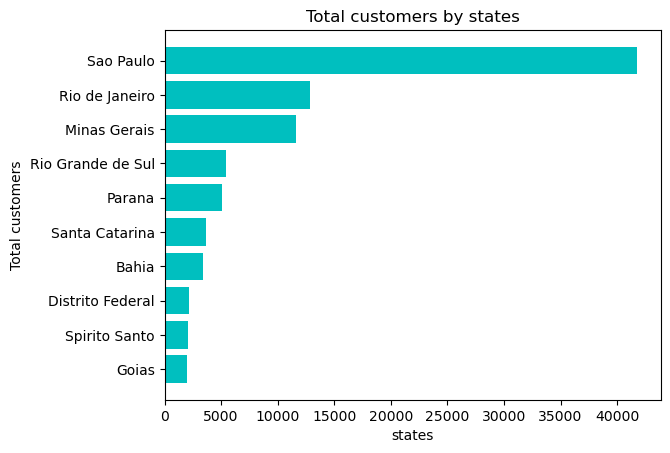

In [48]:
# Bar plot for total customers by states.
plt.figure()

x=totalcustomerbystate['states']
y=totalcustomerbystate['total_customers']
plt.barh(x,y, color="c")
plt.xticks()
plt.xlabel('states')
plt.ylabel('Total customers')
plt.title('Total customers by states')

plt.show()


#### Insights:
-Sao Paulo has highest customer, increase marketing with customer loyality campaigns to improve repeat purchase rate for top 3 states.
-Analyze delivery charges,pricing for remote  but large population states.

## Region segmentation

In [49]:
# Map states into region.
region_map=(
    dict.fromkeys(['AC','AP','AM','PA','RO','RR','TO'],'NORTH') |
dict.fromkeys(['AL','BA','CE','MA','PB','PI','PE','RN','SE'],'NORTH-EAST')|
dict.fromkeys(['DF','GO','MT','MS'],'CENTRAL-WEST') |
dict.fromkeys(['SP','RJ','MG','ES'],'SOUTH-EAST') |
dict.fromkeys(['PR','SC','RS'],'SOUTH')
)
    

In [50]:
df1['region']=df1['customer_state'].map(region_map)
df1

,customer_id,customer_unique_id,customer_city,customer_state,order_status,quantity,spent_price,region
0,d0349571985dc0a748ecdd1b6bf25750,527acd5ee1b69a0edddde8fe512007d9,curitiba,PR,delivered,1.0,177.99,SOUTH
1,8fb17055fd54b0e086d5320642721a88,c667c7454243251d3210c6c54a97c482,janauba,MG,delivered,3.0,345.00,SOUTH-EAST
2,885aa5f046631ec02ead6b2bea798a92,359a78f03d3fa44893db34ed3564c7ef,campinas,SP,delivered,1.0,89.49,SOUTH-EAST
3,3172fe335c9b335ce749eda3b7c73bd3,9e89d2232df792cde636a47212a9f2bb,rio de janeiro,RJ,delivered,1.0,109.90,SOUTH-EAST
4,dac766eabb1289d59cb88e34b1489db1,f9721131784ad9d58ba9278236b37845,sao paulo,SP,delivered,1.0,237.00,SOUTH-EAST
...,...,...,...,...,...,...,...,...
99436,8fa9f17f7cc7af41d068b9b3f8df51e8,5105b52fa696cbca4cd3ddade05149fd,abre campo,MG,canceled,0.0,0.00,SOUTH-EAST
99437,bffd28b4af20bc7b1a477fe80e190c77,20763743ec53eec3a9949781bf459e6e,barra velha,SC,unavailable,0.0,0.00,SOUTH
99438,e016de14d2abd37825c4c485cd780b74,e7bb82dae3998954497289418e677dc2,sao gabriel,RS,canceled,0.0,0.00,SOUTH
99439,a5569eafa093045938b448b5f802032d,5bdff994fa115621df0b714401ec5db4,jau,SP,unavailable,0.0,0.00,SOUTH-EAST


In [51]:
# Merge customer_level table to order_level tabel for region analysis. 
df_merge=df.merge(df1[['customer_id','region']],on='customer_id',how='left')
df_merge

,order_id,order_item_id,price,customer_id,order_status,order_date,delivery_date,estimated_delivery_date,product_id,product_category,yearmonth,repeat_customer,delivery_days,delivery_type,is_delayed,region
0,5f79b5b0931d63f1a42989eb65b9da6e,1,89.80,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:00,2017-11-28 15:41:00,2017-12-04,64315bd8c0c47303179dd2e25b579d00,toys,2017-11,False,-6,on time,False,SOUTH-EAST
1,a44895d095d7e0702b6a162fa2dbeced,1,54.90,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:00,2017-07-25 18:57:00,2017-08-04,84183944dc7cddca87a5d384452c1d3c,health_beauty,2017-07,False,-10,on time,False,SOUTH-EAST
2,316a104623542e4d75189bb372bc5f8d,1,179.99,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:00,2017-03-06 08:57:00,2017-03-22,9df2b21ec85378d71df4404712e17478,baby,2017-02,False,-16,on time,False,SOUTH-EAST
3,5825ce2e88d5346438686b0bba99e5ee,1,149.90,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:00,2017-09-13 20:06:00,2017-09-14,af3ec22cce878225aae6d9eb6c7a78eb,cool_stuff,2017-08,False,-1,on time,False,SOUTH-EAST
4,0ab7fb08086d4af9141453c91878ed7a,1,93.00,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:00,2018-04-13 20:21:00,2018-04-18,868b3136c5b206f91b8208fbfdf2cb7c,bed_bath_table,2018-04,False,-5,on time,False,SOUTH-EAST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,814d6a3a7c0b32b2ad929ac6328124e9,1,54.90,fffecc9f79fd8c764f843e9951b11341,delivered,2018-03-29 16:59:00,2018-04-10 17:20:00,2018-04-27,c045b19fdb30a3035c56d04c6fe2e622,bed_bath_table,2018-03,False,-17,on time,False,SOUTH
112646,8c855550908247a7eff50281b92167a8,1,47.90,fffeda5b6d849fbd39689bb92087f431,delivered,2018-05-22 13:36:00,2018-06-08 18:03:00,2018-06-29,d5c263f4d651ba657c900ce70a4be7de,telephony,2018-05,False,-21,on time,False,SOUTH-EAST
112647,83b5fc912b2862c5046555ded1483ae9,1,199.90,ffff42319e9b2d713724ae527742af25,delivered,2018-06-13 16:57:00,2018-06-18 18:33:00,2018-06-25,e61c78a7343d82c0539d27df0f7dfc31,bed_bath_table,2018-06,False,-7,on time,False,SOUTH-EAST
112648,d0e7be325a1c986babc4e1cdb91edc03,1,10.90,ffffa3172527f765de70084a7e53aae8,delivered,2017-09-02 11:53:00,2017-09-14 19:47:00,2017-09-26,43ee88561093499d9e571d4db5f20b79,furniture_decor,2017-09,False,-12,on time,False,SOUTH-EAST


##  Regional sales analysis

In [52]:
#  Calculate total sales by region.
regionwise_revenue=df_merge.groupby(['region'])['price'].sum().reset_index()
regionwise_revenue=regionwise_revenue.sort_values(['price'],ascending=True)
regionwise_revenue

,region,price
1,NORTH,334353.71
0,CENTRAL-WEST,870462.06
2,NORTH-EAST,1545493.75
3,SOUTH,1953941.12
4,SOUTH-EAST,8887393.06


In [53]:
regionwise_revenue['impact%']=regionwise_revenue['price']/regionwise_revenue['price'].sum() *100
regionwise_revenue['price']=regionwise_revenue['price'].apply(format_revenue)
regionwise_revenue

,region,price,impact%
1,NORTH,334K,2.459995
0,CENTRAL-WEST,870K,6.404391
2,NORTH-EAST,1.55M,11.370911
3,SOUTH,1.95M,14.376047
4,SOUTH-EAST,8.89M,65.388655


In [54]:
print(type(regionwise_revenue))

<class 'pandas.core.frame.DataFrame'>


In [55]:
### Line chart for revenue generated by  all regions.

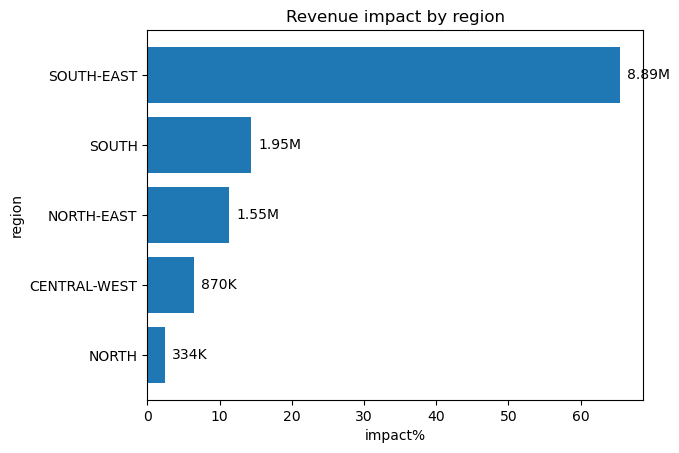

In [56]:
# Plot bar chart.
fig, ax = plt.subplots()

bars=ax.barh(regionwise_revenue['region'],regionwise_revenue['impact%'])

#Add revenue labels on bars
for i,bar in enumerate(bars):
    width= bar.get_width()
    revenue= regionwise_revenue.iloc[i]['price']

    ax.text(width+1,
           bar.get_y() + bar.get_height()/2,
            revenue,
           va='center',
           fontsize=10
           )
    

plt.title('Revenue impact by region')
plt.xlabel('impact%')
plt.ylabel('region')
#plt.tight_layout()
plt.show()

#### Insights:
-Region South-East dominates with 65.38% impact of total revenue, increase marketing/inventory  allocation to South-East to boost  growth.
 
 -North and Central-West combined  has less than 10% impact on total revenue, investigate issue (logistics,competition) and target campaigns.

##  Load order data from Postgresql.

In [57]:
df3=pd.read_sql_query("""select * from product_level""",engine)

In [58]:
df3

,product_id,order_id,product_price,review_score,product_category,review_label
0,00066f42aeeb9f3007548bb9d3f33c38,f30149f4a8882a08895b6a242aa0d612,101.65,5.0,perfumery,very good
1,0009406fd7479715e4bef61dd91f2462,0bf736fd0fd5169d60de3699fcbcf986,229.00,1.0,bed_bath_table,very bad
2,000b8f95fcb9e0096488278317764d19,3aba44d8e554ab4bb8c09f6f78032ca8,58.90,5.0,housewares,very good
3,0011c512eb256aa0dbbb544d8dffcf6e,bb9552306cf6879fde49f4ba3bd94299,52.00,1.0,auto,very bad
4,0011c512eb256aa0dbbb544d8dffcf6e,bb9552306cf6879fde49f4ba3bd94299,52.00,1.0,auto,very bad
...,...,...,...,...,...,...
107585,fff6177642830a9a94a0f2cba5e476d1,e91d77b27ccd3bac6b23a34a44ae3db1,109.99,5.0,cool_stuff,very good
107586,fff9553ac224cec9d15d49f5a263411f,df3a7600e4fd0a2c595fa7ad6e2e622e,32.00,5.0,fashion_bags_accessories,very good
107587,fffdb2d0ec8d6a61f0a0a0db3f25b441,2878b4e373a9556df9aa1708a4e5c3c8,34.99,5.0,computers_accessories,very good
107588,fffdb2d0ec8d6a61f0a0a0db3f25b441,dd38c566a34ff9deb93ff05d7bd6d0aa,34.99,5.0,computers_accessories,very good


##  Find highest generated revenue by products.

In [59]:
total_rev= (df3.groupby(['product_category']).agg({
    'product_id':'count',
    'product_price':'sum'
})
.reset_index())

total_rev=total_rev.sort_values(['product_price'],ascending=False).assign(price=lambda x:x['product_price'].apply(format_revenue))
total_rev

,product_category,product_id,product_price,price
43,health_beauty,9244,1280473.34,1.28M
7,bed_bath_table,11910,1252961.70,1.25M
15,computers_accessories,7332,1171754.31,1.17M
70,watches_gifts,5638,1130473.28,1.13M
65,sports_leisure,8179,1033985.94,1.03M
...,...,...,...,...
35,flowers,26,989.94,989.94
11,cds_dvds_musicals,14,910.00,910.0
46,home_comfort_2,26,714.78,714.78
29,fashion_childrens_clothes,10,649.83,649.8299999999999


In [60]:
total_rev['contribution%']=total_rev['product_price']/ total_rev['product_price'].sum() *100
top_rev_products=total_rev.head(10)
top_rev_products

,product_category,product_id,product_price,price,contribution%
43,health_beauty,9244,1280473.34,1.28M,8.661772
7,bed_bath_table,11910,1252961.70,1.25M,8.475669
15,computers_accessories,7332,1171754.31,1.17M,7.926341
70,watches_gifts,5638,1130473.28,1.13M,7.647095
65,sports_leisure,8179,1033985.94,1.03M,6.994406
39,furniture_decor,8471,966550.40,967K,6.538238
49,housewares,6688,760952.45,761K,5.147469
20,cool_stuff,3549,606602.40,607K,4.103367
42,garden_tools,4158,598393.74,598K,4.047839
5,auto,4057,591014.09,591K,3.997919


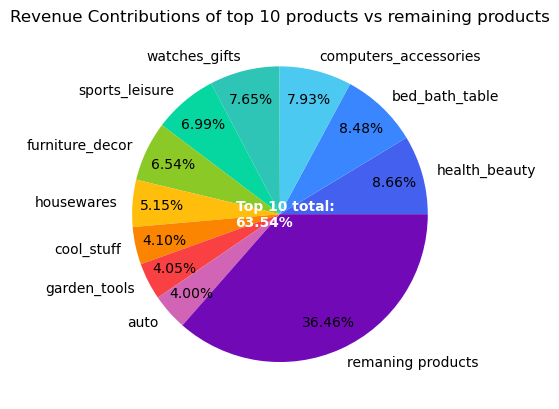

In [61]:
products =list(top_rev_products['product_category'].values)
contributions =list(top_rev_products['contribution%'].values)

top10_contribution =sum(contributions)
remaining_contributions =100 - top10_contribution

products.append('remaning products')
contributions.append(remaining_contributions)

colors = [
    '#4361EE',  # royal blue
    '#3A86FF',  # bright blue
    '#4CC9F0',  # sky cyan
    '#2EC4B6',  # teal
    '#06D6A0',  # mint green
    '#8AC926',  # lime green
    '#FFBE0B',  # amber
    '#FB8500',  # orange
    '#F94144',  # coral red
    '#D264B6',  # pink purple
    '#7209B7'   # deep violet
]

plt.pie(contributions,
       labels= products,
       autopct='%1.2f%%',
       pctdistance=0.80,
       colors= colors )
plt.title('Revenue Contributions of top 10 products vs remaining products') 
plt.text(-0.3,0, f"Top 10 total:\n{top10_contribution:.2f}%",color='white',fontweight='bold',va ='center')
plt.show()

#### Insights:
- Top 10 products contribute on revenue is 63.54 % 
- The remaining products contribute only 36.46%, meaning they are not utilized effectively or may not be as competitive.
-  Increase budget for top 10 products on marketingand inventory also lower budget for remaining product.
-  Evaluate pricing and run offers for less purchased products.

##  Find top 10 highest unit sold products .

In [68]:
# Save csv file
df.to_csv("brazilian_e_commerce.csv",
         index=False,
         header=True)
print("CSV saved succesfully")

CSV saved succesfully
